# COASTDyn 

* Original Data Source: https://zenodo.org/records/16793036
* Reference:  https://opensciencedata.esa.int/products/coastdyn-adt-rep-2d-dataset/collection
* OSC entry: https://opensciencedata.esa.int/products/coastdyn-adt-rep-2d-dataset/collection
* License: CC-BY-4.0

In [1]:
import xarray as xr

In [2]:
ds = xr.open_zarr('https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/coastdyn/coastdyn-miost-l4.zarr/')
ds

<xarray.Dataset> Size: 33GB
Dimensions:           (time: 645, latitude: 930, longitude: 1154, bounds: 2)
Coordinates:
  * time              (time) datetime64[ns] 5kB 2023-03-28 ... 2024-12-31
  * latitude          (latitude) float32 4kB 19.97 20.03 20.09 ... 77.97 78.03
  * longitude         (longitude) float32 5kB -30.03 -29.97 ... 41.97 42.03
    latitude_bounds   (latitude, bounds) float64 15kB dask.array<chunksize=(930, 2), meta=np.ndarray>
    longitude_bounds  (longitude, bounds) float64 18kB dask.array<chunksize=(1154, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    adt               (time, latitude, longitude) float64 6GB dask.array<chunksize=(12, 930, 1154), meta=np.ndarray>
    sla               (time, latitude, longitude) float64 6GB dask.array<chunksize=(12, 930, 1154), meta=np.ndarray>
    ugos              (time, latitude, longitude) float64 6GB dask.array<chunksize=(12, 930, 1154), meta=np.ndarray>
    ugosa             (time, latitude, longitude) float64 6GB dask.array<chunksize=(12, 930, 1154), meta=np.ndarray>
    vgos              (time, latitude, longitude) float64 6GB dask.array<chunksize=(12, 930, 1154), meta=np.ndarray>
    vgosa             (time, latitude, longitude) float64 6GB dask.array<chunksize=(12, 930, 1154), meta=np.ndarray>
Attributes: (12/45)
    description:                      Miost analysis 
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         
    ...                              ...
    summary:                         Experimental SSALTO/DUACS Delayed-Time L...
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    title:                           DT merged all satellites European Seas G...
    time_coverage_start:             2023-03-28T12:00:00Z
    time_coverage_end:               2023-03-28T12:00:00Z

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
import numpy as np

### Select a date of interest

In [4]:
date = "2024-01-25"

### Read dataset & compute magnitude of the geostrophic current

In [5]:
da = ds.sel(time=np.datetime64(date), drop=True)
da['ugeo'] = np.sqrt(da.ugos**2 + da.vgos**2)
da['ugeo'].attrs['long_name'] = 'Magnitude Geostrophic current'
da['ugeo'].attrs['units'] = 'm/s'
da

<xarray.Dataset> Size: 60MB
Dimensions:           (latitude: 930, longitude: 1154, bounds: 2)
Coordinates:
  * latitude          (latitude) float32 4kB 19.97 20.03 20.09 ... 77.97 78.03
  * longitude         (longitude) float32 5kB -30.03 -29.97 ... 41.97 42.03
    latitude_bounds   (latitude, bounds) float64 15kB dask.array<chunksize=(930, 2), meta=np.ndarray>
    longitude_bounds  (longitude, bounds) float64 18kB dask.array<chunksize=(1154, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    adt               (latitude, longitude) float64 9MB dask.array<chunksize=(930, 1154), meta=np.ndarray>
    sla               (latitude, longitude) float64 9MB dask.array<chunksize=(930, 1154), meta=np.ndarray>
    ugos              (latitude, longitude) float64 9MB dask.array<chunksize=(930, 1154), meta=np.ndarray>
    ugosa             (latitude, longitude) float64 9MB dask.array<chunksize=(930, 1154), meta=np.ndarray>
    vgos              (latitude, longitude) float64 9MB dask.array<chunksize=(930, 1154), meta=np.ndarray>
    vgosa             (latitude, longitude) float64 9MB dask.array<chunksize=(930, 1154), meta=np.ndarray>
    ugeo              (latitude, longitude) float64 9MB dask.array<chunksize=(930, 1154), meta=np.ndarray>
Attributes: (12/45)
    description:                      Miost analysis 
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         
    ...                              ...
    summary:                         Experimental SSALTO/DUACS Delayed-Time L...
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    title:                           DT merged all satellites European Seas G...
    time_coverage_start:             2023-03-28T12:00:00Z
    time_coverage_end:               2023-03-28T12:00:00Z

## Plot Absolute Dynamic Topopgraphy example

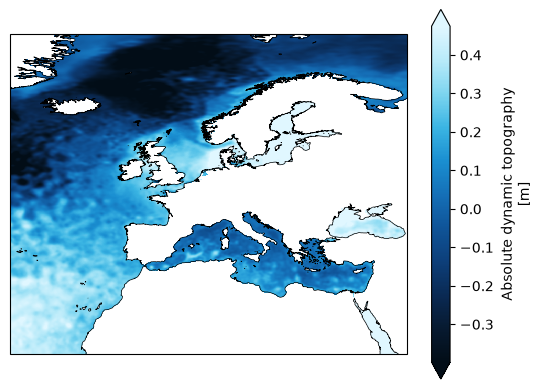

In [7]:
bathymetry = ['#020d17', '#071a30', '#0a2a54', '#0d3f7a', '#0f5498', '#1570b8', '#1a8fd1', '#3bb5e3', '#7dd5f0', '#b8eaf9', '#e0f7ff']

# Create matplotlib colormap for adt
cmap_adt = LinearSegmentedColormap.from_list(
    'bathymetry', bathymetry
)



fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
da.adt.plot(cmap=cmap_adt, 
            vmin=np.nanpercentile(da.adt, 5), 
            vmax=np.nanpercentile(da.adt, 95), 
            transform=ccrs.PlateCarree())
axis.coastlines(resolution='10m', lw=0.5)

# Longitude and latitude gridlines
# remove the gridlines code if you dont see the map.
gl = axis.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 15))

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

plt.show()


## Plot Magnitude of Geostrophic current

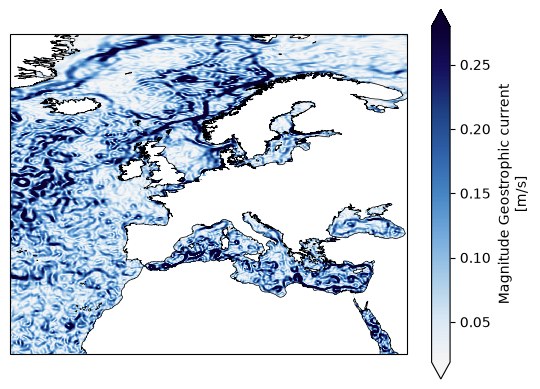

In [8]:
wind_speed = ['#f5f5f5', '#d9e8f5', '#a8cce8', '#74aadc', '#4685c4', '#2f60a8', '#1e3f82', '#150f5c', '#0b0030']

# Create matplotlib colormap for velocity
cmap_u = LinearSegmentedColormap.from_list(
    'wind-speed', wind_speed
)



fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
da.ugeo.plot(cmap=cmap_u, 
            vmin=np.nanpercentile(da.ugeo, 5), 
            vmax=np.nanpercentile(da.ugeo, 95), 
            transform=ccrs.PlateCarree())
axis.coastlines(resolution='10m', lw=0.5) 

# Longitude and latitude gridlines
# remove the gridlines code if you dont see the map.

gl = axis.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 15))

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

plt.show()
